# Travel MLOps: prediction and hotel recommendations

**GitHub repository:** [https://github.com/shubham-maral/Integrating-MLOps-for-Predictive-and-Recommender-Systems-in-Travel-Project](https://github.com/shubham-maral/Integrating-MLOps-for-Predictive-and-Recommender-Systems-in-Travel-Project)

This notebook brings together the models and deployment files in the repository. It uses `flights.csv` for flight-price prediction, `users.csv` for the classification exercise, and `hotels.csv` for hotel recommendations.

The main question is whether booking details can give a useful flight-price estimate. The other two models cover the classification and recommendation parts of the project. Each section includes the code, its output, and the limits of what that output tells us.

## Running the notebook

Open this `.ipynb` file in Google Colab, choose a Python CPU runtime, and use **Runtime → Run all**. A GPU is not needed. The setup cell downloads the repository when the data is not already present and installs only missing packages. The first run needs internet access. Flight training is the longest step.

The same notebook can run in Jupyter from the repository folder. Outputs saved with this submission come from a local Python run; running it in Colab refreshes them in that environment. Package versions and data checksums are recorded below. Generated models and reports are saved under `mlruns/colab_submission/` in the runtime.

## 1. Setup

The download uses the repository revision that this notebook was prepared from, so later changes to the default branch do not silently change the data or API code. When run inside a local checkout, the notebook uses that checkout and records its revision.

In [1]:
from pathlib import Path
import hashlib
import importlib.util
import importlib.metadata
import json
import platform
import subprocess
import sys

REPO_URL = "https://github.com/shubham-maral/Integrating-MLOps-for-Predictive-and-Recommender-Systems-in-Travel-Project"
REPO_REVISION = "d0ffd04db8a252b38f55211a62647c4de57715d3"
REPO_NAME = REPO_URL.rsplit("/", 1)[-1]
required_files = ["flights.csv", "hotels.csv", "users.csv"]

candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / REPO_NAME]
PROJECT_ROOT = next(
    (folder for folder in candidates if all((folder / name).is_file() for name in required_files)
     and (folder / ".git").exists()
     and (folder / "Productionisation_Travel_ML_System" / "Productionisation_ML_Systems" / "app.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd() / REPO_NAME
    if PROJECT_ROOT.exists():
        raise RuntimeError("The download folder exists but is missing data. Use a fresh runtime or check the folder.")
    subprocess.run(["git", "clone", "--quiet", REPO_URL + ".git", str(PROJECT_ROOT)], check=True)
    subprocess.run(["git", "-C", str(PROJECT_ROOT), "checkout", "--quiet", REPO_REVISION], check=True)

PROJECT_ROOT = PROJECT_ROOT.resolve()
ARTIFACT_DIR = PROJECT_ROOT / "mlruns" / "colab_submission"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
SERVICE_DIR = PROJECT_ROOT / "Productionisation_Travel_ML_System" / "Productionisation_ML_Systems"

# Colab already includes most of the numerical stack.
packages = {
    "numpy": "numpy", "pandas": "pandas", "scipy": "scipy",
    "sklearn": "scikit-learn", "matplotlib": "matplotlib",
    "joblib": "joblib", "flask": "Flask", "mlflow": "mlflow>=2.15,<4",
}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *missing], check=True)

revision = subprocess.run(
    ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"],
    capture_output=True, text=True, check=True,
).stdout.strip()
print("Repository:", REPO_URL)
print("Source revision:", revision)
print("Data files ready:", ", ".join(required_files))

Repository: https://github.com/shubham-maral/Integrating-MLOps-for-Predictive-and-Recommender-Systems-in-Travel-Project
Source revision: d0ffd04db8a252b38f55211a62647c4de57715d3
Data files ready: flights.csv, hotels.csv, users.csv


In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.sparse.linalg import svds
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    f1_score, mean_absolute_error, mean_squared_error, r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False})

versions = {name: importlib.metadata.version(name) for name in
            ["numpy", "pandas", "scipy", "scikit-learn", "matplotlib", "joblib", "Flask", "mlflow"]}
environment = {"python": platform.python_version(), "packages": versions, "source_revision": revision}
(ARTIFACT_DIR / "environment.json").write_text(json.dumps(environment, indent=2), encoding="utf-8")
print("Python:", environment["python"])
display(pd.Series(versions, name="installed_version").to_frame())

Python: 3.11.9


,installed_version
numpy,1.26.4
pandas,2.2.2
scipy,1.13.1
scikit-learn,1.5.1
matplotlib,3.11.1
joblib,1.4.2
Flask,3.0.3
mlflow,2.15.1


## 2. Read and check the data

`users.code` links to `userCode` in the flight and hotel tables. `travelCode` identifies trips. These identifiers help check the data, but the flight model does not use them as predictors.

The audit checks sizes, missing values, duplicate rows, dates, and user references before training. Full passenger names are not needed in the displayed tables.

In [3]:
flights = pd.read_csv(PROJECT_ROOT / "flights.csv")
hotels = pd.read_csv(PROJECT_ROOT / "hotels.csv")
users = pd.read_csv(PROJECT_ROOT / "users.csv")
datasets = {"flights": flights, "hotels": hotels, "users": users}

audit = pd.DataFrame([
    {"dataset": name, "rows": len(frame), "columns": frame.shape[1],
     "missing_cells": int(frame.isna().sum().sum()), "duplicate_rows": int(frame.duplicated().sum())}
    for name, frame in datasets.items()
]).set_index("dataset")
display(audit)
display(pd.concat([
    pd.DataFrame({"dataset": name, "column": frame.columns, "dtype": frame.dtypes.astype(str).values,
                  "missing": frame.isna().sum().values})
    for name, frame in datasets.items()
], ignore_index=True))

checksums = {name: hashlib.sha256((PROJECT_ROOT / name).read_bytes()).hexdigest() for name in required_files}
(ARTIFACT_DIR / "data_checksums.json").write_text(json.dumps(checksums, indent=2), encoding="utf-8")
display(pd.Series(checksums, name="sha256").to_frame())

,rows,columns,missing_cells,duplicate_rows
dataset,,,,
flights,271888,10,0,0
hotels,40552,8,0,0
users,1340,5,0,0


,dataset,column,dtype,missing
0,flights,travelCode,int64,0
1,flights,userCode,int64,0
2,flights,from,object,0
3,flights,to,object,0
4,flights,flightType,object,0
5,flights,price,float64,0
6,flights,time,float64,0
7,flights,distance,float64,0
8,flights,agency,object,0
9,flights,date,object,0


,sha256
flights.csv,d223ef92841d871b26a6a148aaf755075a9bafc0856efe...
hotels.csv,18b21c8e9ca406c6332b15446b2e6f1c10928df142fc70...
users.csv,d551fa03528b1c79e090ab6c3c4fa17eeed8d7e78dcfdf...


In [4]:
assert users["code"].is_unique, "User identifiers must be unique."
assert not any(frame.isna().any().any() for frame in datasets.values()), "Review missing values before training."
assert flights["userCode"].isin(users["code"]).all()
assert hotels["userCode"].isin(users["code"]).all()
assert (flights["price"] > 0).all() and (hotels["price"] > 0).all()
assert (hotels["days"] > 0).all()
assert np.allclose(hotels["price"] * hotels["days"], hotels["total"])

flight_dates = pd.to_datetime(flights["date"], format="%m/%d/%Y", errors="raise")
hotel_dates = pd.to_datetime(hotels["date"], format="%m/%d/%Y", errors="raise")
display(pd.DataFrame({
    "first_date": [flight_dates.min().date(), hotel_dates.min().date()],
    "last_date": [flight_dates.max().date(), hotel_dates.max().date()],
}, index=["flights", "hotels"]))
display(users["gender"].value_counts(dropna=False).rename("users").to_frame())
print("Data checks passed. No rows have been dropped from flights or hotels.")

,first_date,last_date
flights,2019-09-26,2023-07-24
hotels,2019-09-26,2023-07-13


,users
gender,
male,452
female,448
none,440


Data checks passed. No rows have been dropped from flights or hotels.


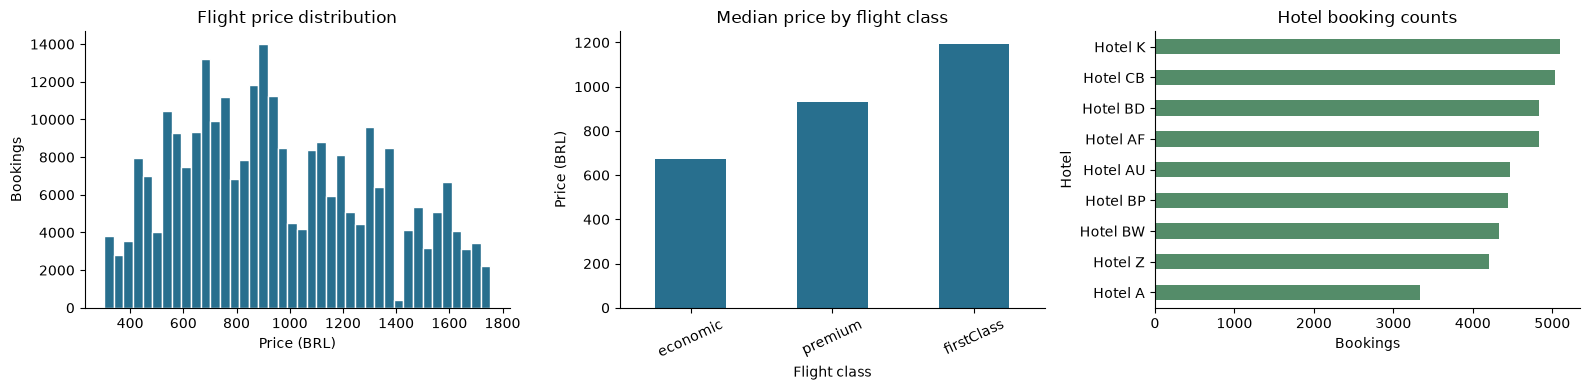

,price,time,distance
count,271888.00,271888.00,271888.00
mean,957.38,1.42,546.96
std,362.31,0.54,208.85
min,301.51,0.44,168.22
25%,672.66,1.04,401.66
50%,904.00,1.46,562.14
75%,1222.24,1.76,676.53
max,1754.17,2.44,937.77


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(flights["price"], bins=40, color="#286f8e", edgecolor="white")
axes[0].set(title="Flight price distribution", xlabel="Price (BRL)", ylabel="Bookings")
flights.groupby("flightType")["price"].median().sort_values().plot.bar(ax=axes[1], color="#286f8e", rot=25)
axes[1].set(title="Median price by flight class", xlabel="Flight class", ylabel="Price (BRL)")
hotels["name"].value_counts().sort_values().plot.barh(ax=axes[2], color="#548c69")
axes[2].set(title="Hotel booking counts", xlabel="Bookings", ylabel="Hotel")
fig.tight_layout()
plt.show()

display(flights[["price", "time", "distance"]].describe().round(2))

## 3. Flight-price prediction

This follows the feature set and Random Forest settings in [`flight-price-pred-mlflow.py`](https://github.com/shubham-maral/Integrating-MLOps-for-Predictive-and-Recommender-Systems-in-Travel-Project/blob/d0ffd04db8a252b38f55211a62647c4de57715d3/Productionisation_Travel_ML_System/Productionisation_ML_Systems/flight-price-pred-mlflow.py).

Inputs are the origin, destination, flight class, agency, and three date fields. Duration and distance are left out to stay consistent with the existing API. One-hot encoding is fitted inside the training pipeline, so the test set does not influence category fitting.

The repository uses an 80/20 random split. A mean-price baseline gives the Random Forest something simple to beat. This tests performance on randomly held-out bookings; a time-based holdout is still needed before treating the result as a forecast of future prices.

In [6]:
def make_flight_features(frame):
    dates = pd.to_datetime(frame["date"], format="%m/%d/%Y")
    features = frame[["from", "to", "flightType", "agency"]].copy()
    features["week_no"] = dates.dt.isocalendar().week.astype(int)
    features["week_day"] = dates.dt.weekday
    features["day"] = dates.dt.day
    return features

X = make_flight_features(flights)
y = flights["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

categorical_columns = ["from", "to", "flightType", "agency"]
numeric_columns = ["week_no", "week_day", "day"]
preprocessing = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
    ("numeric", "passthrough", numeric_columns),
])
flight_model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", RandomForestRegressor(
        n_estimators=100, max_depth=15, min_samples_split=10,
        random_state=SEED, n_jobs=-1,
    )),
])
print(f"Training bookings: {len(X_train):,}; test bookings: {len(X_test):,}")
display(X_train.head())

train_trips = set(flights.loc[X_train.index, "travelCode"])
test_trips = set(flights.loc[X_test.index, "travelCode"])
print(f"Trips present in both partitions: {len(train_trips & test_trips):,}")
print("A grouped split by travelCode would keep each trip entirely in one partition.")

Training bookings: 217,510; test bookings: 54,378


,from,to,flightType,agency,week_no,week_day,day
111401,Recife (PE),Campo Grande (MS),firstClass,Rainbow,25,5,20
129167,Aracaju (SE),Campo Grande (MS),economic,Rainbow,46,0,11
179742,Florianopolis (SC),Salvador (BH),premium,Rainbow,31,3,30
52639,Aracaju (SE),Brasilia (DF),firstClass,FlyingDrops,7,4,14
68769,Recife (PE),Brasilia (DF),premium,Rainbow,6,4,7


Trips present in both partitions: 43,496
A grouped split by travelCode would keep each trip entirely in one partition.


In [7]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
baseline_prediction = baseline.predict(X_test)

flight_model.fit(X_train, y_train)
flight_prediction = flight_model.predict(X_test)

def regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
    }

flight_results = pd.DataFrame({
    "Mean-price baseline": regression_metrics(y_test, baseline_prediction),
    "Random Forest": regression_metrics(y_test, flight_prediction),
}).T
display(flight_results.round(4))
flight_results.to_csv(ARTIFACT_DIR / "flight_metrics.csv", index_label="model")

,MAE,RMSE,R2
Mean-price baseline,304.7753,363.0010,-0.0000
Random Forest,13.1285,48.4034,0.9822


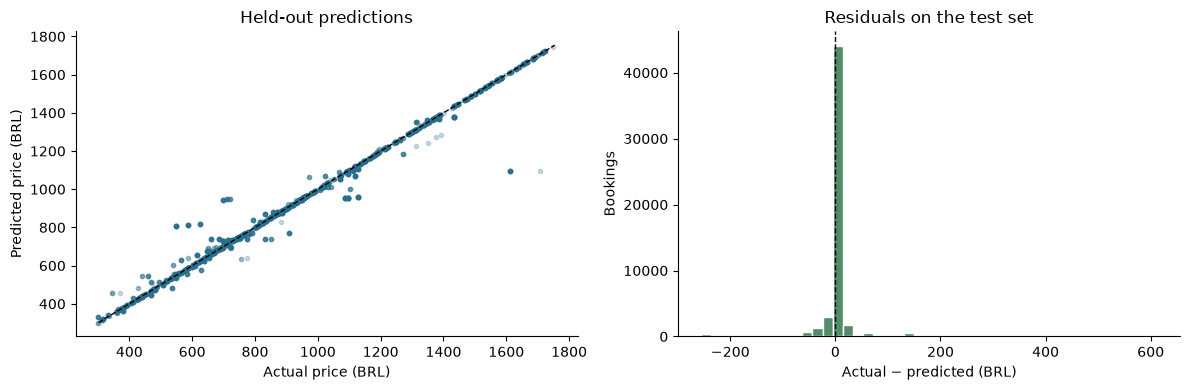

The Random Forest has a test MAE of **13.13 BRL** and an RMSE of **48.40 BRL**. The change in MAE against the mean-price baseline is **95.7%** (positive means lower error). These figures describe this split, not a production guarantee.

In [8]:
comparison = pd.DataFrame({"actual": y_test, "predicted": flight_prediction})
comparison["residual"] = comparison["actual"] - comparison["predicted"]
plot_sample = comparison.sample(n=min(3000, len(comparison)), random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(plot_sample["actual"], plot_sample["predicted"], s=9, alpha=0.25, color="#286f8e")
limits = [comparison[["actual", "predicted"]].min().min(), comparison[["actual", "predicted"]].max().max()]
axes[0].plot(limits, limits, "--", color="black", linewidth=1)
axes[0].set(title="Held-out predictions", xlabel="Actual price (BRL)", ylabel="Predicted price (BRL)")
axes[1].hist(comparison["residual"], bins=45, color="#548c69", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set(title="Residuals on the test set", xlabel="Actual − predicted (BRL)", ylabel="Bookings")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "flight_diagnostics.png", dpi=140, bbox_inches="tight")
plt.show()

rf_metrics = flight_results.loc["Random Forest"]
mae_change = 100 * (1 - rf_metrics["MAE"] / flight_results.loc["Mean-price baseline", "MAE"])
display(Markdown(
    f"The Random Forest has a test MAE of **{rf_metrics['MAE']:.2f} BRL** and an RMSE of "
    f"**{rf_metrics['RMSE']:.2f} BRL**. The change in MAE against the mean-price baseline is "
    f"**{mae_change:.1f}%** (positive means lower error). These figures describe this split, not a production guarantee."
))

### Save the fitted pipeline

The artifact includes the encoder and the regressor. Saving them together avoids a separate manual encoding step at prediction time. A reload check verifies that the saved model gives the same answers on a small test sample.

In [9]:
flight_model_path = ARTIFACT_DIR / "flight_price_model.joblib"
joblib.dump(flight_model, flight_model_path)
saved_flight_model = joblib.load(flight_model_path)
np.testing.assert_allclose(
    saved_flight_model.predict(X_test.head(10)), flight_model.predict(X_test.head(10)),
)
print("Saved pipeline reload check passed:", flight_model_path.name)

Saved pipeline reload check passed: flight_price_model.joblib


## 4. Track the flight experiment with MLflow

The local SQLite tracking database stores the run settings and metrics. The fitted pipeline, diagnostic plot, data checksums, and package versions are logged as artifacts. No tracking server or account is required for this run. The pipeline is stored as a joblib artifact; this section does not register or deploy a model.

Reference: [MLflow tracking with a local database](https://www.mlflow.org/docs/latest/ml/tracking/tutorials/local-database/).

In [10]:
import mlflow

tracking_database = (ARTIFACT_DIR / "tracking.db").resolve().as_posix()
mlflow.set_tracking_uri("sqlite:///" + tracking_database)
experiment_name = "travel-colab-flight-price"
experiment = mlflow.get_experiment_by_name(experiment_name)
if experiment is None:
    experiment_id = mlflow.create_experiment(
        experiment_name, artifact_location=(ARTIFACT_DIR / "mlflow_artifacts").resolve().as_uri(),
    )
else:
    experiment_id = experiment.experiment_id

with mlflow.start_run(experiment_id=experiment_id, run_name="random-forest-100-trees") as run:
    mlflow.log_params({
        "model": "RandomForestRegressor", "n_estimators": 100, "max_depth": 15,
        "min_samples_split": 10, "random_state": SEED, "test_size": 0.2,
        "train_rows": len(X_train), "test_rows": len(X_test), "split": "random",
    })
    mlflow.set_tags({"repository": REPO_URL, "source_revision": revision})
    mlflow.log_metrics({key.lower(): float(value) for key, value in rf_metrics.items()})
    for filename in ["flight_price_model.joblib", "flight_metrics.csv", "flight_diagnostics.png",
                     "environment.json", "data_checksums.json"]:
        mlflow.log_artifact(str(ARTIFACT_DIR / filename))
    run_id = run.info.run_id

tracked_run = mlflow.get_run(run_id)
assert tracked_run.info.status == "FINISHED"
assert np.isclose(tracked_run.data.metrics["mae"], rf_metrics["MAE"])
print("Completed MLflow run:", run_id)
display(pd.Series(tracked_run.data.metrics, name="logged_value").to_frame())

C:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\utils\requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


2026/10/06 23:44:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/10/06 23:44:08 INFO mlflow.store.db.utils: Updating database tables


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


...

INFO  [alembic.runtime.migration] Running upgrade 5b0e9adcef9c -> 4465047574b1, increase max dataset schema size


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


Completed MLflow run: d44c7b87250f4d88bb5122fd50abfb4e


,logged_value
mae,13.128530
rmse,48.403431
r2,0.982220


## 5. Check the existing Flask API

The notebook loads the repository's `app.py` and points it to the model saved above. Flask's test client exercises the actual routes inside the notebook, without starting a background web server.

The API accepts a date in `YYYY-MM-DD` format; the CSV stores dates as `MM/DD/YYYY`. The valid-request check also compares the API response with a direct pipeline prediction. Missing fields and a malformed date should return HTTP 400.

In [11]:
def load_source_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

api_module = load_source_module("travel_colab_api", SERVICE_DIR / "app.py")
api_module.MODEL_PATH = flight_model_path
api_module.app.config.update(TESTING=True)

sample_index = X_test.index[0]
sample_booking = flights.loc[sample_index]
payload = {column: str(sample_booking[column]) for column in categorical_columns}
payload["date"] = pd.to_datetime(sample_booking["date"], format="%m/%d/%Y").strftime("%Y-%m-%d")

with api_module.app.test_client() as client:
    home_response = client.get("/")
    valid_response = client.post("/predict", json=payload)
    missing_response = client.post("/predict", json={"from": payload["from"]})
    invalid_response = client.post("/predict", json={**payload, "date": "not-a-date"})

assert home_response.status_code == 200
assert valid_response.status_code == 200
assert missing_response.status_code == 400
assert invalid_response.status_code == 400
expected_price = round(float(flight_model.predict(X_test.loc[[sample_index]])[0]), 2)
assert valid_response.get_json()["predicted_price"] == expected_price
assert valid_response.get_json()["currency"] == "BRL"

print("Example request:", json.dumps(payload, indent=2))
print("API response:", valid_response.get_json())
display(pd.DataFrame([
    {"check": "Home page", "HTTP status": home_response.status_code},
    {"check": "Valid prediction matches saved model", "HTTP status": valid_response.status_code},
    {"check": "Missing required fields", "HTTP status": missing_response.status_code},
    {"check": "Invalid date", "HTTP status": invalid_response.status_code},
]))

Example request: {
  "from": "Florianopolis (SC)",
  "to": "Rio de Janeiro (RJ)",
  "flightType": "premium",
  "agency": "Rainbow",
  "date": "2022-04-07"
}
API response: {'currency': 'BRL', 'predicted_price': 471.96}


,check,HTTP status
0,Home page,200
1,Valid prediction matches saved model,200
2,Missing required fields,400
3,Invalid date,400


## 6. Gender-classification exercise

This section reproduces the separate classification script: character n-grams from the name, one-hot encoded company, scaled age, and logistic regression. Preprocessing is fitted only on the training partition.

The source data has `male`, `female`, and `none` labels. Only the two recorded labels are used for this supervised baseline; the excluded count is shown below. This measures agreement with the supplied labels and cannot establish a person's gender identity. The model is included for the project exercise, and its predictions are not used by the recommender or flight API.

In [12]:
labelled_users = users.loc[users["gender"].isin(["male", "female"])].copy()
print(f"Labelled records: {len(labelled_users):,}; excluded unknown labels: {len(users) - len(labelled_users):,}")
gender_X_train, gender_X_test, gender_y_train, gender_y_test = train_test_split(
    labelled_users[["name", "company", "age"]], labelled_users["gender"],
    test_size=0.2, random_state=SEED, stratify=labelled_users["gender"],
)

gender_features = ColumnTransformer([
    ("name", TfidfVectorizer(analyzer="char", ngram_range=(2, 4), min_df=2), "name"),
    ("company", OneHotEncoder(handle_unknown="ignore"), ["company"]),
    ("age", StandardScaler(), ["age"]),
])
gender_model = Pipeline([
    ("features", gender_features),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED)),
])
gender_model.fit(gender_X_train, gender_y_train)
gender_prediction = gender_model.predict(gender_X_test)
gender_baseline = DummyClassifier(strategy="most_frequent")
gender_baseline.fit(gender_X_train, gender_y_train)
gender_baseline_prediction = gender_baseline.predict(gender_X_test)

gender_results = pd.DataFrame([
    {"model": name, "accuracy": accuracy_score(gender_y_test, predicted),
     "macro_f1": f1_score(gender_y_test, predicted, average="macro")}
    for name, predicted in [("Majority-class baseline", gender_baseline_prediction),
                            ("Logistic regression", gender_prediction)]
]).set_index("model")
display(gender_results.round(4))
print(classification_report(gender_y_test, gender_prediction, zero_division=0))
gender_results.to_csv(ARTIFACT_DIR / "gender_metrics.csv", index_label="model")
joblib.dump(gender_model, ARTIFACT_DIR / "gender_classifier.joblib")

Labelled records: 900; excluded unknown labels: 440


,accuracy,macro_f1
model,,
Majority-class baseline,0.5000,0.3333
Logistic regression,0.8222,0.8211


              precision    recall  f1-score   support

      female       0.88      0.74      0.81        90
        male       0.78      0.90      0.84        90

    accuracy                           0.82       180
   macro avg       0.83      0.82      0.82       180
weighted avg       0.83      0.82      0.82       180



['E:\\z github local repo\\Integrating-MLOps-for-Predictive-and-Recommender-Systems-in-Travel-Project\\mlruns\\colab_submission\\gender_classifier.joblib']

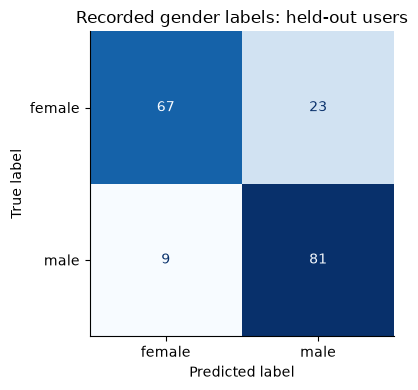

Accuracy is **82.2%** on **180** held-out labelled users. The small test set and name-based features limit how far this result can be generalized.

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    gender_y_test, gender_prediction, labels=["female", "male"],
    ax=ax, cmap="Blues", colorbar=False,
)
ax.set_title("Recorded gender labels: held-out users")
fig.tight_layout()
plt.show()

gender_accuracy = gender_results.loc["Logistic regression", "accuracy"]
display(Markdown(
    f"Accuracy is **{gender_accuracy:.1%}** on **{len(gender_y_test)}** held-out labelled users. "
    "The small test set and name-based features limit how far this result can be generalized."
))

## 7. Hotel recommendations

The Streamlit application groups bookings by user and hotel, sums the `price` column, and applies truncated SVD to the resulting matrix. The same calculation is shown here. Note that `price` is the daily price; the existing algorithm does not use the full-stay `total`.

These interaction weights are an indirect preference signal. Hotel prices are fixed within this dataset, so the weights mix hotel price and booking frequency. They are not user ratings or probabilities. The default recommendation list includes hotels a user has already booked, matching the application. An optional filter below can return only unseen hotels when any are available.

In [14]:
interactions = hotels.groupby(["userCode", "name"], as_index=False)["price"].sum()
hotel_matrix = interactions.pivot(index="userCode", columns="name", values="price").fillna(0)
visited_counts = hotel_matrix.gt(0).sum(axis=1)
coverage = float(hotel_matrix.gt(0).to_numpy().mean())

display(pd.DataFrame({
    "value": [len(hotel_matrix), hotel_matrix.shape[1], coverage,
              int(visited_counts.min()), int(visited_counts.max()),
              int((visited_counts == hotel_matrix.shape[1]).sum())]
}, index=["Users with hotel bookings", "Hotels", "Matrix density",
          "Fewest hotels visited per user", "Most hotels visited per user", "Users who visited every hotel"]))
display(hotels.groupby("name").agg(bookings=("userCode", "size"), distinct_daily_prices=("price", "nunique")))

k = min(8, min(hotel_matrix.shape) - 1)
assert k >= 1, "SVD needs at least two users and two hotels."
u, singular_values, vt = svds(hotel_matrix.to_numpy(dtype=float), k=k, random_state=SEED)
hotel_scores = pd.DataFrame(u @ np.diag(singular_values) @ vt,
                            index=hotel_matrix.index, columns=hotel_matrix.columns)
assert np.isfinite(hotel_scores.to_numpy()).all()
print(f"SVD factors: {k}; matrix: {hotel_matrix.shape[0]} users × {hotel_matrix.shape[1]} hotels")

,value
Users with hotel bookings,1310.000000
Hotels,9.000000
Matrix density,0.824767
Fewest hotels visited per user,1.000000
Most hotels visited per user,9.000000
Users who visited every hotel,376.000000


,bookings,distinct_daily_prices
name,,
Hotel A,3330,1
Hotel AF,4828,1
Hotel AU,4467,1
Hotel BD,4829,1
Hotel BP,4437,1
Hotel BW,4333,1
Hotel CB,5029,1
Hotel K,5094,1
Hotel Z,4205,1


SVD factors: 8; matrix: 1310 users × 9 hotels


In [15]:
def recommend_hotels(user_code, top_n=5, only_unseen=False):
    if not isinstance(top_n, (int, np.integer)) or top_n < 1:
        raise ValueError("top_n must be a positive integer.")
    if user_code not in hotel_scores.index:
        raise ValueError("This user has no hotel history in the dataset.")
    scores = hotel_scores.loc[user_code].copy()
    if only_unseen:
        scores = scores[hotel_matrix.loc[user_code].eq(0)]
    return scores.nlargest(top_n).rename_axis("hotel").reset_index(name="recommendation_score")

example_user = int(hotel_scores.index[0])  # Change this to another userCode with hotel history.
recommendations = recommend_hotels(example_user)
assert recommendations["hotel"].is_unique
assert recommendations["recommendation_score"].is_monotonic_decreasing
assert len(recommendations) == min(5, hotel_matrix.shape[1])
print("Example userCode:", example_user)
display(recommendations.round(2))

unseen_recommendations = recommend_hotels(example_user, only_unseen=True)
if unseen_recommendations.empty:
    print("This example user has already booked every hotel in the catalogue.")
else:
    assert hotel_matrix.loc[example_user, unseen_recommendations["hotel"]].eq(0).all()
    print("Hotels this user has not booked:")
    display(unseen_recommendations.round(2))

recommendations.to_csv(ARTIFACT_DIR / "example_hotel_recommendations.csv", index=False)

Example userCode: 0


,hotel,recommendation_score
0,Hotel K,1839.80
1,Hotel BD,968.33
2,Hotel A,939.20
3,Hotel AU,625.44
4,Hotel Z,624.35


This example user has already booked every hotel in the catalogue.


### Check recommendations on later bookings

The demonstration above uses all bookings. For evaluation, a separate model uses only bookings on or before the 80th-percentile booking date. The test target is each user's first booking after that cutoff, restricted to users with some training history. This keeps future bookings out of the fitted matrix.

Hit@K measures whether the next booked hotel appears in the top K suggestions. A global booking-count ranking is the baseline. Previously booked hotels remain eligible, so this is a repeat-booking task. With only nine hotels, a top-five hit is a fairly generous criterion. Users with no earlier history are counted separately and excluded from this warm-user comparison.

In [16]:
dated_hotels = hotels.assign(booking_date=hotel_dates)
cutoff = dated_hotels["booking_date"].quantile(0.8)
hotel_train = dated_hotels.loc[dated_hotels["booking_date"] <= cutoff]
hotel_later = dated_hotels.loc[dated_hotels["booking_date"] > cutoff]
next_bookings = hotel_later.sort_values(["booking_date", "travelCode"]).groupby("userCode", as_index=False).head(1)

train_matrix = hotel_train.pivot_table(index="userCode", columns="name", values="price", aggfunc="sum", fill_value=0)
warm_mask = next_bookings["userCode"].isin(train_matrix.index)
cold_user_count = int((~warm_mask).sum())
hotel_test = next_bookings.loc[warm_mask]
assert not hotel_test.empty
assert hotel_train["booking_date"].max() < hotel_test["booking_date"].min()

eval_k = min(8, min(train_matrix.shape) - 1)
eval_u, eval_s, eval_vt = svds(train_matrix.to_numpy(dtype=float), k=eval_k, random_state=SEED)
eval_scores = pd.DataFrame(eval_u @ np.diag(eval_s) @ eval_vt, index=train_matrix.index, columns=train_matrix.columns)
popularity_order = hotel_train["name"].value_counts().index.tolist()
rankings = {user_code: eval_scores.loc[user_code].sort_values(ascending=False).index.tolist()
            for user_code in hotel_test["userCode"]}

hotel_evaluation = pd.DataFrame([
    {"K": top_k,
     "SVD Hit@K": np.mean([row.name in rankings[row.userCode][:top_k] for row in hotel_test.itertuples(index=False)]),
     "Popularity Hit@K": np.mean(hotel_test["name"].isin(popularity_order[:top_k]))}
    for top_k in [1, 3, 5]
]).set_index("K")
print("Training cutoff:", cutoff.date())
print(f"Training bookings: {len(hotel_train):,}; later bookings: {len(hotel_later):,}")
print(f"Evaluated next-booking users: {len(hotel_test):,}; excluded users without history: {cold_user_count}")
display(hotel_evaluation.round(4))
hotel_evaluation.to_csv(ARTIFACT_DIR / "hotel_temporal_metrics.csv")
display(Markdown(
    f"At K=3, the SVD hit rate is **{hotel_evaluation.loc[3, 'SVD Hit@K']:.1%}**, compared with "
    f"**{hotel_evaluation.loc[3, 'Popularity Hit@K']:.1%}** for popularity. "
    "This is evidence for a limited next-booking test, not an assessment of satisfaction or unseen-hotel discovery."
))

Training cutoff: 2021-11-25
Training bookings: 32,595; later bookings: 7,957
Evaluated next-booking users: 574; excluded users without history: 0


,SVD Hit@K,Popularity Hit@K
K,,
1,0.1167,0.1202
3,0.3972,0.3659
5,0.5784,0.5645


At K=3, the SVD hit rate is **39.7%**, compared with **36.6%** for popularity. This is evidence for a limited next-booking test, not an assessment of satisfaction or unseen-hotel discovery.

The recommender's ranking checks and later-booking evaluation answer different questions: the first checks that the code behaves as expected, while the second compares its suggestions with observed choices. Users with no booking history still need a fallback before the application could serve new customers.

The interactive version is in [`Hotel_Recommender_System/streamlit_app.py`](https://github.com/shubham-maral/Integrating-MLOps-for-Predictive-and-Recommender-Systems-in-Travel-Project/blob/d0ffd04db8a252b38f55211a62647c4de57715d3/Hotel_Recommender_System/streamlit_app.py). Its interface can be started from a local terminal with `python -m streamlit run Hotel_Recommender_System/streamlit_app.py` after installing the repository requirements.

## 8. How the deployment files fit together

The flight training script saves a pipeline; Flask loads it for predictions. Docker packages that API and its model, Kubernetes describes the service and replicas, Airflow schedules training, and Jenkins installs dependencies and runs the training script.

| Part | Repository file | What this notebook establishes |
|---|---|---|
| Flight training | `flight-price-pred-mlflow.py` | Same features and Random Forest settings trained and evaluated above |
| REST API | `app.py` | Existing routes checked with the newly saved model |
| Experiment tracking | MLflow | A completed local run with metrics and artifacts |
| Container | `Dockerfile` | Configuration inspected; image not built here |
| Kubernetes | `deployment.yml`, `service.yml` | Configuration inspected; cluster not deployed here |
| Orchestration | `flight_price_prediction_dag.py` | DAG source inspected; scheduler not run here |
| CI | `Jenkinsfile` | Pipeline source inspected; Jenkins job not run here |
| Recommendation UI | `streamlit_app.py` | Core recommendation calculation run above; UI not hosted here |

The next cell displays the deployment files so they can be reviewed alongside the experiments.

In [17]:
deployment_files = [
    SERVICE_DIR / "Dockerfile",
    SERVICE_DIR / "deployment.yml",
    SERVICE_DIR / "service.yml",
    SERVICE_DIR / "flight_price_prediction_dag.py",
    PROJECT_ROOT / "Jenkinsfile",
]
for path in deployment_files:
    print("\n" + str(path.relative_to(PROJECT_ROOT)))
    print(path.read_text(encoding="utf-8"))


Productionisation_Travel_ML_System\Productionisation_ML_Systems\Dockerfile
FROM python:3.11-slim
WORKDIR /app
COPY requirements-api.txt .
RUN pip install --no-cache-dir -r requirements-api.txt
COPY app.py .
COPY templates ./templates
COPY model ./model
EXPOSE 8000
CMD ["python", "app.py"]


Productionisation_Travel_ML_System\Productionisation_ML_Systems\deployment.yml
apiVersion: apps/v1
kind: Deployment
metadata:
  name: flight-price-prediction
spec:
  replicas: 3
  selector:
    matchLabels:
      app: flight-price-prediction
  template:
    metadata:
      labels:
        app: flight-price-prediction
    spec:
      containers:
        - name: api
          image: YOUR_DOCKERHUB_USERNAME/flight-price-prediction:latest
          ports:
            - containerPort: 8000
          resources:
            requests: { cpu: "100m", memory: "128Mi" }
            limits: { cpu: "500m", memory: "512Mi" }
          readinessProbe:
            httpGet: { path: /, port: 8000 }
            initi

### Steps still needed outside the notebook

- The Docker build expects a model under the service's `model/` folder. Run the repository training script in the deployment environment to generate it using that environment's pinned dependencies. A model trained with a newer Colab scikit-learn version should not be assumed compatible with the older container version.
- Replace `YOUR_DOCKERHUB_USERNAME` in `deployment.yml` with the image location after building and pushing the image. The manifest declares three fixed replicas; it does not configure autoscaling.
- The container currently launches the Flask development server with debugging enabled. A deployment intended for real traffic needs a production server configuration. The readiness probe checks the home page, which does not establish that the model can be loaded.
- The Airflow DAG derives the project root from its own file location. Copying just the DAG to another directory requires adjusting `PROJECT_ROOT` and making the repository available to the worker. Its Airflow dependencies must be installed separately.
- The Jenkinsfile uses Windows `bat` steps. Its stage named “Smoke test API” runs Python compilation only. The request checks in this notebook are more specific, but are not yet part of that Jenkins pipeline.

These files document the intended deployment path. A successful notebook run does not demonstrate that a container, cluster, scheduler, or CI server has been deployed.

## 9. Results and next steps

The following summary is calculated from this run. It is kept separate from the deployment notes because model evaluation and service deployment answer different questions.

In [18]:
summary = {
    "repository": REPO_URL,
    "source_revision": revision,
    "flight_test_rows": len(X_test),
    "flight_random_forest": {key.lower(): float(value) for key, value in rf_metrics.items()},
    "flight_baseline": {key.lower(): float(value) for key, value in flight_results.loc["Mean-price baseline"].items()},
    "gender_test_rows": len(gender_y_test),
    "gender_accuracy": float(gender_accuracy),
    "gender_macro_f1": float(gender_results.loc["Logistic regression", "macro_f1"]),
    "hotel_users": len(hotel_matrix),
    "hotel_catalogue_size": hotel_matrix.shape[1],
    "hotel_evaluation_users": len(hotel_test),
    "hotel_svd_hit_at_3": float(hotel_evaluation.loc[3, "SVD Hit@K"]),
    "hotel_popularity_hit_at_3": float(hotel_evaluation.loc[3, "Popularity Hit@K"]),
    "mlflow_run_id": run_id,
    "api_checks_passed": 4,
}
(ARTIFACT_DIR / "results_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
display(pd.DataFrame([
    {"task": "Flight prediction", "result": f"MAE {rf_metrics['MAE']:.2f} BRL; R² {rf_metrics['R2']:.4f}"},
    {"task": "Gender exercise", "result": f"Accuracy {gender_accuracy:.1%}; macro F1 {summary['gender_macro_f1']:.4f}"},
    {"task": "Hotel recommendations", "result": f"Later-booking Hit@3 {summary['hotel_svd_hit_at_3']:.1%}; popularity {summary['hotel_popularity_hit_at_3']:.1%}"},
    {"task": "Flask API", "result": "4 checks passed, including direct-model agreement"},
    {"task": "MLflow", "result": "Finished run; metrics read back successfully"},
]))
print("Saved report:", "mlruns/colab_submission/results_summary.json")

,task,result
0,Flight prediction,MAE 13.13 BRL; R² 0.9822
1,Gender exercise,Accuracy 82.2%; macro F1 0.8211
2,Hotel recommendations,Later-booking Hit@3 39.7%; popularity 36.6%
3,Flask API,"4 checks passed, including direct-model agreement"
4,MLflow,Finished run; metrics read back successfully


Saved report: mlruns/colab_submission/results_summary.json


The flight model can now be compared with a simple baseline and called through the existing API. The next evaluation should split flights by date, and possibly by trip, to check how much the random split benefits from repeated travel patterns. The date features also omit the year, so behavior across years needs separate attention.

The classification result covers only labelled users in this dataset. The hotel section compares ranked suggestions against later bookings, but its price-weighted signal, small catalogue, and single date cutoff limit the claim. Several time cutoffs and an explicit cold-start baseline would give a stronger assessment.

For reproducibility, this run saves the model pipelines, metrics, package versions, dataset checksums, and MLflow run information. Colab runtime files are temporary; download any artifacts you want to keep before the runtime is cleared.

## Submission

1. Run all cells and check that the final results table appears without errors.
2. Save a copy of this notebook in Google Drive or download the completed `.ipynb` file.
3. If the submission form asks for a Colab link, share the saved notebook with the required reviewer access and submit that link. If it accepts files, attach the `.ipynb`.
4. Keep the GitHub repository link in the opening cell. It is also repeated here: [https://github.com/shubham-maral/Integrating-MLOps-for-Predictive-and-Recommender-Systems-in-Travel-Project](https://github.com/shubham-maral/Integrating-MLOps-for-Predictive-and-Recommender-Systems-in-Travel-Project).

Google's [Colab FAQ](https://research.google.com/colaboratory/faq.html) explains notebook storage, sharing, and runtime behavior.